In [5]:
import numpy as np
import scipy.io as sio
import os
from scipy.signal import spectrogram, istft
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Input, Conv1D, LSTM, Cropping1D, Concatenate, GlobalAveragePooling1D, Dense, Multiply, Activation, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import shutil

In [6]:
primary_order = ["power", "forward", "backward", "up", "down", "noise"]

def load_data(mic_dir, us_dir, test_ratio=0.1, seed=None):
    # 1) gather mic ↔ us paths and labels
    def gather(dir):
        paths, labels = [], []
        for root, _, files in os.walk(dir):
            for f in files:
                if f.endswith(".mat"):
                    paths.append(os.path.join(root, f))
                    labels.append(f.split("_")[1].lower())
        return np.array(paths), np.array(labels)

    mic_paths, mic_labels = gather(mic_dir)
    us_paths,  us_labels  = gather(us_dir)

    # sanity
    if not np.array_equal(mic_labels, us_labels):
        raise ValueError("MIC/US labels do not line up!")

    # 2) sort by (label_rank, chunk number)
    def label_rank(l): 
        return primary_order.index(l) if l in primary_order else len(primary_order)
    def chunk_num(p):
        # assumes filename ends in "_chunkNN.mat"
        stem = Path(p).stem
        return int(stem.split("_")[-1].lstrip("chunk"))

    order = sorted(
        range(len(mic_paths)),
        key=lambda i: (label_rank(mic_labels[i]), chunk_num(mic_paths[i]))
    )
    mic_paths = mic_paths[order]
    us_paths  = us_paths[order]
    labels_all= mic_labels[order]

    # 3) split per‐label
    train_mic, train_us, train_lbl = [], [], []
    test_mic,  test_us,  test_lbl  = [], [], []

    rng = np.random.RandomState(seed)
    for lbl in primary_order:
        idxs = np.where(labels_all == lbl)[0]
        if len(idxs)==0:
            # you might want to warn here if you expected some
            continue

        # shuffle within this label
        rng.shuffle(idxs)

        n_test  = max(1, int(len(idxs) * test_ratio))
        n_train = len(idxs) - n_test

        tr = idxs[:n_train]
        te = idxs[n_train:]

        train_mic += mic_paths[tr].tolist()
        train_us  += us_paths[tr].tolist()
        train_lbl += labels_all[tr].tolist()

        test_mic  += mic_paths[te].tolist()
        test_us   += us_paths[te].tolist()
        test_lbl  += labels_all[te].tolist()

    # 4) final global shuffle of train set
    train_mic = np.array(train_mic)
    train_us  = np.array(train_us)
    train_lbl = np.array(train_lbl)
    perm = rng.permutation(len(train_mic))
    train_mic = train_mic[perm]
    train_us  = train_us[perm]
    train_lbl = train_lbl[perm]

    test_mic  = np.array(test_mic)
    test_us   = np.array(test_us)
    test_lbl  = np.array(test_lbl)

    return train_mic, train_us, train_lbl, test_mic, test_us, test_lbl

In [7]:
train_mic, train_us, train_labels, \
test_mic,  test_us,  test_labels = load_data(
    mic_dir="MIES_data/Mic/CHUNKS",
    us_dir ="MIES_data/US/CHUNKS"
)

print("Train:", train_mic.shape, train_labels.shape)  # (100,), (100,)
print("Test: ", test_mic.shape,  test_labels.shape)   # (10,) , (10,)

Train: (268,) (268,)
Test:  (27,) (27,)


In [8]:
np.unique(train_labels, return_counts=True)

(array(['backward', 'down', 'forward', 'noise', 'power', 'up'], dtype='<U8'),
 array([40, 40, 40, 68, 40, 40]))

In [9]:
# build your mapping
label2idx = {lbl: i for i, lbl in enumerate(primary_order)}

train_labels = np.array([ label2idx[l] for l in train_labels ], dtype=np.int32)
test_labels  = np.array([ label2idx[l] for l in test_labels  ], dtype=np.int32)


In [10]:
_MEL_FILTER = tf.signal.linear_to_mel_weight_matrix(
    num_mel_bins=64,
    num_spectrogram_bins=1024//2 + 1,  # 513
    sample_rate=25_000,
    lower_edge_hertz=0.0,
    upper_edge_hertz=12_500.0,         # fs/2
    dtype=tf.float32,
)

def mic_mel_spec_tf(
    signal,
    fs: int = 25_000,
    n_fft: int = 1024,
    hop_length: int = 256,
    n_mels: int = 64,
    power: float = 2.0,
    to_db: bool = True,
):
    """
    Compute a (log‑)Mel spectrogram from a 1‑D mono signal tensor.
    Works inside tf.data / keras.Sequence pipelines (no .numpy() call needed).
    Returns: Tensor shape (time_frames, n_mels)  dtype float32
    """

    signal = tf.cast(signal, tf.float32)

    stft = tf.signal.stft(
        signal,
        frame_length=n_fft,
        frame_step=hop_length,
        fft_length=n_fft,
        window_fn=tf.signal.hann_window,  # good default
        pad_end=False,
    )
    spectrogram = tf.abs(stft) ** power   # (frames, n_fft//2+1)
    
    with tf.device('/CPU:0'):
        mel_filter = tf.signal.linear_to_mel_weight_matrix(
            num_mel_bins=n_mels,
            num_spectrogram_bins=n_fft // 2 + 1,
            sample_rate=fs,
            lower_edge_hertz=0.0,
            upper_edge_hertz=fs / 2.0,
            dtype=tf.float32,
        )

    mel_spec = tf.matmul(spectrogram, mel_filter)  # (frames, n_mels)

    if to_db:
        amin = 1e-10  # avoid log(0)
        mel_spec = 10.0 * tf.math.log(tf.maximum(mel_spec, amin)) / tf.math.log(10.0)
        mel_spec = tf.clip_by_value(mel_spec, -80.0, 20.0)
    return mel_spec              


In [11]:
def us_bandpassed_spec_tf(
    signal,
    fs: int = 100_000,           # ultrasound sampling rate [Hz]
    low_cut: float = 25_000.0,   # keep ≥ 25 kHz …
    high_cut: float = 50_000.0,  # … and ≤ 60 kHz   (must be ≤ fs/2)
    n_fft: int = 2048,
    hop_length: int = 512,
    power: float = 2.0,          # 1.0 → magnitude, 2.0 → power
    to_db: bool = True,
):

    nyq = fs / 2.0
    if high_cut > nyq:
        raise ValueError(
            f"`high_cut` ({high_cut/1e3:.1f} kHz) must be < Nyquist ({nyq/1e3:.1f} kHz). "
            "Sample faster or lower `high_cut`."
        )
    if low_cut <= 0.0:
        raise ValueError("`low_cut` must be > 0 Hz.")

    signal = tf.reshape(signal, [-1])
    signal = tf.cast(signal, tf.float32)

    sig_len = tf.shape(signal)[0]
    tf.debugging.assert_positive(sig_len, message="Empty mic signal!")

    tf.debugging.assert_positive(n_fft,        message="n_fft is 0")
    tf.debugging.assert_positive(hop_length,   message="hop_length is 0")
    
    # ---------- STFT ----------
    stft = tf.signal.stft(
        signal,
        frame_length=n_fft,
        frame_step=hop_length,
        fft_length=n_fft,
        window_fn=tf.signal.hann_window,
        pad_end=True,
    )                                     
    spec = tf.abs(stft) ** power         

    freqs = tf.linspace(0.0, nyq, n_fft // 2 + 1)   # (n_fft//2 + 1,)
    band_mask = (freqs >= low_cut) & (freqs <= high_cut)
    kept_indices = tf.where(band_mask)[:, 0]        # 1‑D int32

    spec_band = tf.gather(spec, kept_indices, axis=-1)   # (T, kept_bins)
    f_band    = tf.gather(freqs, kept_indices)           # (kept_bins,)

    if to_db:
        spec_band = 10.0 * tf.math.log(tf.maximum(spec_band, 1e-10)) / tf.math.log(10.0)
        spec_band = tf.clip_by_value(spec_band, -80.0, 20.0)          # optional

    return spec_band

In [12]:
def tf_dataloader(
    mic_paths,
    us_paths,
    labels,
    batch_size: int = 16,
    shuffle: bool = True,
):

    ds = tf.data.Dataset.from_tensor_slices(
        (mic_paths, us_paths, labels)
    )

    if shuffle:
        ds = ds.shuffle(len(mic_paths), reshuffle_each_iteration=True)

    def _load_pair(mic_path, us_path, label):
        def _py_loader(m_path, u_path):
            # 1. load *.mat (SciPy runs in Python space)
            mic_sig = sio.loadmat(m_path.numpy().decode("utf-8"))["x_chunk"].squeeze()
            mic_sig = mic_sig.astype(np.float32)
            us_sig  = sio.loadmat(u_path.numpy().decode("utf-8"))["x_chunk"].squeeze()
            us_sig  = us_sig.astype(np.float32)
            
            tf.debugging.assert_positive(tf.shape(mic_sig)[0])
            # 2. time‑series → spectrogram tensors
            mic_spec = mic_mel_spec_tf(mic_sig)
            us_spec  = us_bandpassed_spec_tf(us_sig)

            return mic_spec, us_spec

        mic_spec, us_spec = tf.py_function(
            func=_py_loader,
            inp=[mic_path, us_path],
            Tout=[tf.float32, tf.float32],
        )

 # Normalize mic_spec and us_spec to [0, 1]
        mic_spec = (mic_spec - tf.reduce_min(mic_spec)) / (tf.reduce_max(mic_spec) - tf.reduce_min(mic_spec))
        us_spec = (us_spec - tf.reduce_min(us_spec)) / (tf.reduce_max(us_spec) - tf.reduce_min(us_spec))
   
        # Suppose you decide every mic spectrogram will be padded/truncated to exactly 192 frames:
        mic_spec = tf.pad(mic_spec,
                        [[0, 192 - tf.shape(mic_spec)[0]], [0, 0]],
                        constant_values=-80.0)[:192, :]
        mic_spec.set_shape([192, 64])

        # And every US spectrogram to 391 frames:
        us_spec = tf.pad(us_spec,
                        [[0, 391 - tf.shape(us_spec)[0]], [0, 0]],
                        constant_values=-80.0)[:391, :]
        us_spec.set_shape([391, 513])

        return (mic_spec, us_spec), label   # Keras expects (inputs, target)

    ds = ds.map(_load_pair)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [13]:
train_ds = tf_dataloader(
    mic_paths=train_mic,
    us_paths=train_us,
    labels=train_labels,
    batch_size=16,
    shuffle=True,
)
test_ds = tf_dataloader(
    mic_paths=test_mic,
    us_paths=test_us,
    labels=test_labels,
    batch_size=10,
    shuffle=False,
)

In [15]:
NUM_CLASSES = 6

# 🎤 Mic branch
mic_in = Input(shape=(192, 64), name="mic_input")
mic = BatchNormalization(name="mic_input_norm")(mic_in)
mic = Conv1D(8, 3, padding="same", activation="relu", name="mic_conv1")(mic)
mic = Conv1D(8, 3, padding="same", strides=2, activation="relu", name="mic_conv2")(mic)  # → 96
mic = Conv1D(8, 3, padding="same", strides=2, activation="relu", name="mic_conv3")(mic)  # → 48
mic = Conv1D(8, 3, padding="same", activation="relu", name="mic_resize_conv")(mic)       # → (48, 8)
mic = LSTM(8, return_sequences=True, name="mic_lstm")(mic)

# 🎧 US branch
us_in = Input(shape=(391, 513), name="us_input")
us = Conv1D(4, 3, padding="same", strides=4, activation="relu", name="us_conv1")(us_in)   # → ~98
us = Conv1D(4, 3, padding="same", strides=2, activation="relu", name="us_conv2")(us)   # → ~49
us = Conv1D(4, 3, padding="same", activation="relu", name="us_conv3")(us)              # → ~49
us = Cropping1D(cropping=(0, 1), name="us_crop")(us)                                   # → (48, 4)
us = LSTM(4, return_sequences=True, name="us_lstm")(us)

# 🔀 Fusion
fused = Concatenate(axis=-1, name="fuse_lstm_outputs")([mic, us])  # → (48, 12)

# 🧠 Attention in latent space
x = Conv1D(16, 3, padding="same", activation="relu", name="fused_deep_conv1")(fused)
x = Conv1D(16, 1, padding="same", activation="relu", name="fused_deep_conv2")(x)

attn = Conv1D(16, 1, padding="same", activation="sigmoid", name="attention_gate")(x)
x = Multiply(name="apply_attention")([x, attn])  # → (48, 16)

# 🔁 Temporal reduction
x = LSTM(24, name="fused_lstm")(x)

# 🔚 Classifier head
x = Dense(24, activation="relu", name="dense_relu1")(x)
x = Dense(12, activation="relu", name="dense_relu2")(x)
out = Dense(NUM_CLASSES, activation="softmax", name="output_softmax")(x)

model = Model(inputs=[mic_in, us_in], outputs=out, name="lstm_fusion_attention_model")


In [16]:
model.summary()

Model: "lstm_fusion_attention_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mic_input           │ (None, 192, 64)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mic_input_norm      │ (None, 192, 64)   │        256 │ mic_input[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ us_input            │ (None, 391, 513)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mic_conv1 (Conv1D)  │ (None, 192, 8)    │      1,544 │ mic_input_norm[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ us_conv1 (Conv1D)   │ (None, 98, 4)     │      6,160 │ us_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mic_conv2 (Conv1D)  │ (None, 96, 8)     │        200 │ mic_conv1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ us_conv2 (Conv1D)   │ (None, 49, 4)     │         52 │ us_conv1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mic_conv3 (Conv1D)  │ (None, 48, 8)     │        200 │ mic_conv2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ us_conv3 (Conv1D)   │ (None, 49, 4)     │         52 │ us_conv2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mic_resize_conv     │ (None, 48, 8)     │        200 │ mic_conv3[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ us_crop             │ (None, 48, 4)     │          0 │ us_conv3[0][0]    │
│ (Cropping1D)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mic_lstm (LSTM)     │ (None, 48, 8)     │        544 │ mic_resize_conv[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ us_lstm (LSTM)      │ (None, 48, 4)     │        144 │ us_crop[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fuse_lstm_outputs   │ (None, 48, 12)    │          0 │ mic_lstm[0][0],   │
│ (Concatenate)       │                   │            │ us_lstm[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fused_deep_conv1    │ (None, 48, 16)    │        592 │ fuse_lstm_output… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fused_deep_conv2    │ (None, 48, 16)    │        272 │ fused_deep_conv1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_gate      │ (None, 48, 16)    │        272 │ fused_deep_conv2… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ apply_attention     │ (None, 48, 16)    │          0 │ fused_deep_conv2… │
│ (Multiply)          │                   │            │ attention_gate[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fused_lstm (LSTM)   │ (None, 24)        │      3,936 │ apply_attention[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_relu1 (Dense) │ (None, 24)        │        600 │ fused_lstm[0][0]

 Total params: 15,402 (60.16 KB)

 Trainable params: 15,274 (59.66 KB)

 Non-trainable params: 128 (512.00 B)

In [17]:
# callbacks
es = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)
ckpt = ModelCheckpoint(
    "best_model_micro.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

# train
history = model.fit(
    train_ds,
    epochs=100,
    validation_data=test_ds,
    callbacks=[es, ckpt]
)

# final evaluation
loss, acc = model.evaluate(test_ds)
print(f"Test loss: {loss:.4f}, accuracy: {acc:.4%}")

Epoch 1/100


/opt/anaconda3/envs/dl_env/lib/python3.9/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['mic_input', 'us_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(
2025-04-25 00:16:25.699158: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.1608 - loss: 1.7920
Epoch 1: val_loss improved from inf to 1.78991, saving model to best_model_micro.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 721ms/step - accuracy: 0.1635 - loss: 1.7920 - val_accuracy: 0.2593 - val_loss: 1.7899
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.2449 - loss: 1.7899
Epoch 2: val_loss improved from 1.78991 to 1.78794, saving model to best_model_micro.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 668ms/step - accuracy: 0.2454 - loss: 1.7898 - val_accuracy: 0.2593 - val_loss: 1.7879
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.2754 - loss: 1.7818
Epoch 3: val_loss improved from 1.78794 to 1.77573, saving model to best_model_micro.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 682ms/step - accuracy: 0.2728 - loss: 1.7815 - val_accuracy: 0.2222 - val_loss: 1.7757
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.1583 - loss: 1.7476
Epoch 4: val_loss improved from 1.77573 t

In [13]:
model.save("model_micro.keras")

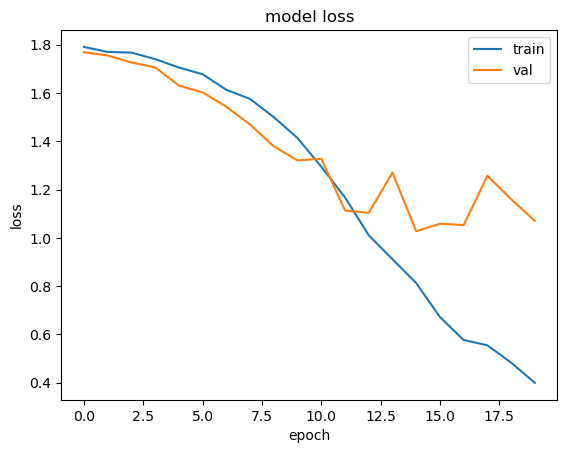

In [14]:
# plot loss curve from training
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

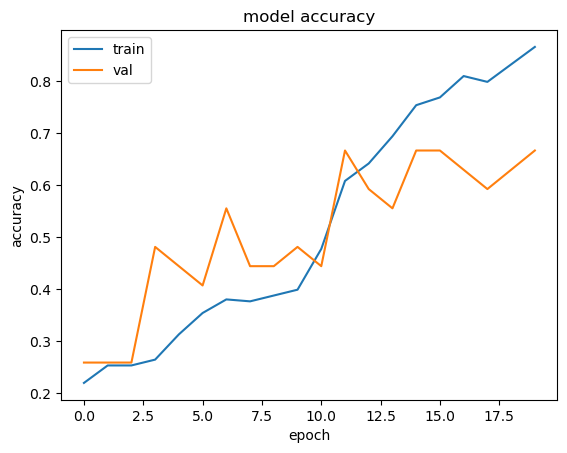

In [15]:
# training accuracy plot
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

In [16]:
mic_example = mic_mel_spec_tf(sio.loadmat(train_mic[0])["x_chunk"].squeeze()).numpy()
us_example = us_bandpassed_spec_tf(sio.loadmat(train_us[0])["x_chunk"].squeeze()).numpy()

# add batch dimension
mic_example = np.expand_dims(mic_example, axis=0)
us_example = np.expand_dims(us_example, axis=0)
print("mic_example shape:", mic_example.shape)  # (1, 192, 64)
print("us_example shape:", us_example.shape)    # (1, 391, 513)

mic_example shape: (1, 192, 64)
us_example shape: (1, 391, 513)


In [17]:
model_loaded = tf.keras.models.load_model('model_micro.keras')

In [18]:
model_loaded.summary()

Model: "tiny_fusion_lstm_attn_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mic_input           │ (None, 192, 64)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ us_input            │ (None, 391, 513)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mic_conv1 (Conv1D)  │ (None, 192, 8)    │      1,544 │ mic_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ us_conv1 (Conv1D)   │ (None, 98, 4)     │      6,160 │ us_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mic_conv2 (Conv1D)  │ (None, 96, 8)     │        200 │ mic_conv1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ us_conv2 (Conv1D)   │ (None, 49, 4)     │         52 │ us_conv1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mic_conv3 (Conv1D)  │ (None, 48, 8)     │        200 │ mic_conv2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ us_conv3 (Conv1D)   │ (None, 49, 4)     │         52 │ us_conv2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mic_resize_conv     │ (None, 48, 8)     │        200 │ mic_conv3[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ us_crop             │ (None, 48, 4)     │          0 │ us_conv3[0][0]    │
│ (Cropping1D)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fuse_mic_us         │ (None, 48, 12)    │          0 │ mic_resize_conv[… │
│ (Concatenate)       │                   │            │ us_crop[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fused_deep_conv1    │ (None, 48, 16)    │        592 │ fuse_mic_us[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fused_deep_conv2    │ (None, 48, 16)    │        272 │ fused_deep_conv1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_gate      │ (None, 48, 16)    │        272 │ fused_deep_conv2… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ apply_attention     │ (None, 48, 16)    │          0 │ fused_deep_conv2… │
│ (Multiply)          │                   │            │ attention_gate[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fused_lstm (LSTM)   │ (None, 24)        │      3,936 │ apply_attention[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_relu1 (Dense) │ (None, 24)        │        600 │ fused_lstm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_relu2 (Dense) │ (None, 12)        │        300 │ dense_relu1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_softmax      │ (None, 6)         │         78 │ dense_relu2[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 43,376 (169.44 KB)

 Trainable params: 14,458 (56.48 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28,918 (112.96 KB)

In [19]:
# print("Before saving:", model.get_layer("multi_head_attention").count_params())
